In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('datasets_ml/data_featured.csv')
df.columns

Index(['Url', 'Brand', 'Model', 'Limited', 'CaseMaterialGrouped', 'Glass',
       'Case Shape', 'CaseDiameterGrouped', 'WaterResistanceLevel',
       'DialColorGrouped', 'DialHandsGrouped', 'Dial Indexes', 'LogPrice'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6288 entries, 0 to 6287
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Url                   6288 non-null   object 
 1   Brand                 6288 non-null   object 
 2   Model                 6288 non-null   object 
 3   Limited               6288 non-null   object 
 4   CaseMaterialGrouped   6288 non-null   object 
 5   Glass                 6288 non-null   object 
 6   Case Shape            6288 non-null   object 
 7   CaseDiameterGrouped   6288 non-null   object 
 8   WaterResistanceLevel  6288 non-null   object 
 9   DialColorGrouped      6288 non-null   object 
 10  DialHandsGrouped      6288 non-null   object 
 11  Dial Indexes          6288 non-null   object 
 12  LogPrice              5132 non-null   float64
dtypes: float64(1), object(12)
memory usage: 638.8+ KB


In [6]:
cat_columns = ['Brand', 'Model', 'Limited', 'CaseMaterialGrouped', 'Glass',
       'Case Shape', 'CaseDiameterGrouped', 'WaterResistanceLevel',
       'DialColorGrouped', 'DialHandsGrouped', 'Dial Indexes']

df[cat_columns] = df[cat_columns].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6288 entries, 0 to 6287
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Url                   6288 non-null   object  
 1   Brand                 6288 non-null   category
 2   Model                 6288 non-null   category
 3   Limited               6288 non-null   category
 4   CaseMaterialGrouped   6288 non-null   category
 5   Glass                 6288 non-null   category
 6   Case Shape            6288 non-null   category
 7   CaseDiameterGrouped   6288 non-null   category
 8   WaterResistanceLevel  6288 non-null   category
 9   DialColorGrouped      6288 non-null   category
 10  DialHandsGrouped      6288 non-null   category
 11  Dial Indexes          6288 non-null   category
 12  LogPrice              5132 non-null   float64 
dtypes: category(11), float64(1), object(1)
memory usage: 184.5+ KB


In [7]:
df = df[df['LogPrice'].notna()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5132 entries, 0 to 6287
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Url                   5132 non-null   object  
 1   Brand                 5132 non-null   category
 2   Model                 5132 non-null   category
 3   Limited               5132 non-null   category
 4   CaseMaterialGrouped   5132 non-null   category
 5   Glass                 5132 non-null   category
 6   Case Shape            5132 non-null   category
 7   CaseDiameterGrouped   5132 non-null   category
 8   WaterResistanceLevel  5132 non-null   category
 9   DialColorGrouped      5132 non-null   category
 10  DialHandsGrouped      5132 non-null   category
 11  Dial Indexes          5132 non-null   category
 12  LogPrice              5132 non-null   float64 
dtypes: category(11), float64(1), object(1)
memory usage: 192.9+ KB


In [8]:
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import xgboost
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, make_scorer
from sklearn.inspection import permutation_importance

In [9]:
X = df.drop(columns=['Url', 'LogPrice'])
y = df['LogPrice']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42)  # 0.1765 ~ 15/(85)

print("Số mẫu: Train:", X_train.shape[0], "| Validation:", X_val.shape[0], "| Test:", X_test.shape[0])

Số mẫu: Train: 3591 | Validation: 514 | Test: 1027


In [10]:
cat_columns = ['Brand', 'Model', 'Limited', 'CaseMaterialGrouped', 'Glass',
       'Case Shape', 'CaseDiameterGrouped', 'WaterResistanceLevel',
       'DialColorGrouped', 'DialHandsGrouped', 'Dial Indexes']

encoder = TargetEncoder(cols=cat_columns)
X_train_enc = encoder.fit_transform(X_train, y_train)
X_val_enc = encoder.transform(X_val)
X_test_enc = encoder.transform(X_test)

In [11]:
def evaluate_performance(y_true, y_pred, phase=""):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    # accuracy = 100 - mape

    print(f"{phase} Performance Evaluation:")
    print(f"R2: {r2:.4f} \t| RMSE: {rmse:.4f} \t| MAE: {mae:.4f}")

    # return r2, rmse, mae, mape, accuracy

In [13]:
evals_result = {}

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    objective='reg:squarederror',
    verbosity=3,
    random_state=42,
    eval_metric="rmse",
)

model.fit(
    X_train_enc, 
    y_train, 
    eval_set=[(X_train_enc, y_train), (X_val_enc, y_val)]
)

y_val_pred = model.predict(X_val_enc)
y_test_pred = model.predict(X_test_enc)

evaluate_performance(y_val, y_val_pred, phase="Validation")
evaluate_performance(y_test, y_test_pred, phase="Test")

[23:04:12] ======== Monitor (0): HostSketchContainer ========
[23:04:12] AllReduce: 0.000213s, 1 calls @ 213us

[23:04:12] MakeCuts: 0.000244s, 1 calls @ 244us

[23:04:12] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (3591, 11, 39501).
[23:04:12] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (514, 11, 5654).
[23:04:12] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:131: Using tree method: 0
[0]	validation_0-rmse:0.99830	validation_1-rmse:0.98696
[1]	validation_0-rmse:0.91962	validation_1-rmse:0.91181
[2]	validation_0-rmse:0.84963	validation_1-rmse:0.84524
[3]	validation_0-rmse:0.78802	validation_1-rmse:0.78808
[4]	validation_0-rmse:0.73352	validation_1-rmse:0.73646
[5]	validation_0-rmse:0.68563	validation_1-rmse:0.69017


[6]	validation_0-rmse:0.64359	validation_1-rmse:0.65123
[7]	validation_0-rmse:0.60607	validation_1-rmse:0.61671
[8]	validation_0-rmse:0.57317	validation_1-rmse:0.58600
[9]	validation_0-rmse:0.54500	validation_1-rmse:0.56057
[10]	validation_0-rmse:0.51988	validation_1-rmse:0.53764
[11]	validation_0-rmse:0.49846	validation_1-rmse:0.51730
[12]	validation_0-rmse:0.47958	validation_1-rmse:0.49981
[13]	validation_0-rmse:0.46321	validation_1-rmse:0.48498
[14]	validation_0-rmse:0.44886	validation_1-rmse:0.47220
[15]	validation_0-rmse:0.43638	validation_1-rmse:0.46053
[16]	validation_0-rmse:0.42541	validation_1-rmse:0.45065
[17]	validation_0-rmse:0.41622	validation_1-rmse:0.44115
[18]	validation_0-rmse:0.40809	validation_1-rmse:0.43384
[19]	validation_0-rmse:0.40013	validation_1-rmse:0.42777
[20]	validation_0-rmse:0.39341	validation_1-rmse:0.42228
[21]	validation_0-rmse:0.38747	validation_1-rmse:0.41814
[22]	validation_0-rmse:0.38260	validation_1-rmse:0.41401
[23]	validation_0-rmse:0.37808	vali

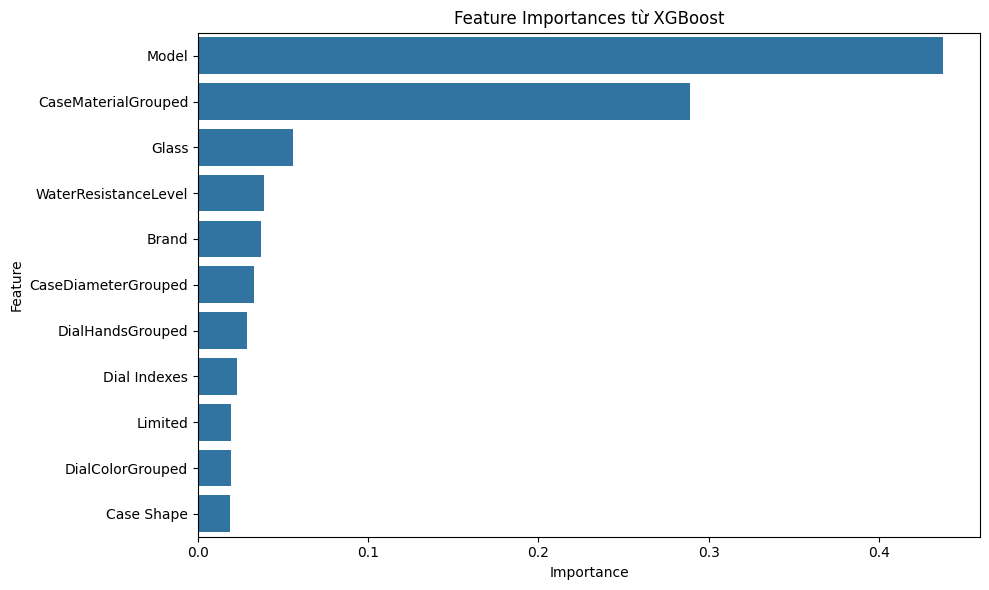

In [14]:
importances = model.feature_importances_
features = X_train_enc.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importances từ XGBoost")
plt.tight_layout()
plt.grid(False)
plt.show()


In [15]:
_, X_demo, _, y_demo = train_test_split(df.drop(columns=['LogPrice']), df['LogPrice'], test_size=0.2, random_state=42)

idx = 0

sample = X_demo.iloc[[idx]]
sample_pool = encoder.transform(sample.drop(columns=['Url']))

log_price_pred = model.predict(sample_pool)

price_pred = np.exp(log_price_pred)

print(sample['Url'].values[0])
print(f"Giá gốc: {np.exp(y_demo.iloc[idx]):.4f}")
print(f"Dự đoán: {price_pred[0]:.2f}")

https://watchbase.com/rolex/datejust-31/278275-0033
Giá gốc: 31101.0000
Dự đoán: 29652.52


In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_enc, y_train)

print("Best parameters found:", grid.best_params_)
print("Best R2 score on validation:", grid.best_score_)


Best parameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 1.0}
Best R2 score on validation: 0.8729875836796608


In [17]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

In [18]:
best_xgb = grid.best_estimator_

stacking_model = StackingRegressor(
    estimators=[('xgb', best_xgb)],
    final_estimator=Ridge(alpha=1.0),
    passthrough=True,
    n_jobs=-1
)

stacking_model.fit(X_train_enc, y_train)

y_val_pred = stacking_model.predict(X_val_enc)
evaluate_performance(y_val, y_val_pred, phase="Stacking Validate with Tuned XGB")
y_test_pred = stacking_model.predict(X_test_enc)
evaluate_performance(y_test, y_test_pred, phase="Stacking Test with Tuned XGB")


Stacking Validate with Tuned XGB Performance Evaluation:
R2: 0.8827 	| RMSE: 0.3673 	| MAE: 0.2654
Stacking Test with Tuned XGB Performance Evaluation:
R2: 0.8733 	| RMSE: 0.3877 	| MAE: 0.2716


In [24]:
_, X_demo, _, y_demo = train_test_split(df.drop(columns=['LogPrice']), df['LogPrice'], test_size=0.2, random_state=42)

idx = 0

sample = X_demo.iloc[[idx]]
sample_pool = encoder.transform(sample.drop(columns=['Url']))

log_price_pred = stacking_model.predict(sample_pool)

price_pred = np.exp(log_price_pred)

print(sample['Url'].values[0])
print(f"Giá gốc: {np.exp(y_demo.iloc[idx]):.4f}")
print(f"Dự đoán: {price_pred[0]:.2f}")

https://watchbase.com/rolex/datejust-31/278275-0033
Giá gốc: 31101.0000
Dự đoán: 31129.93


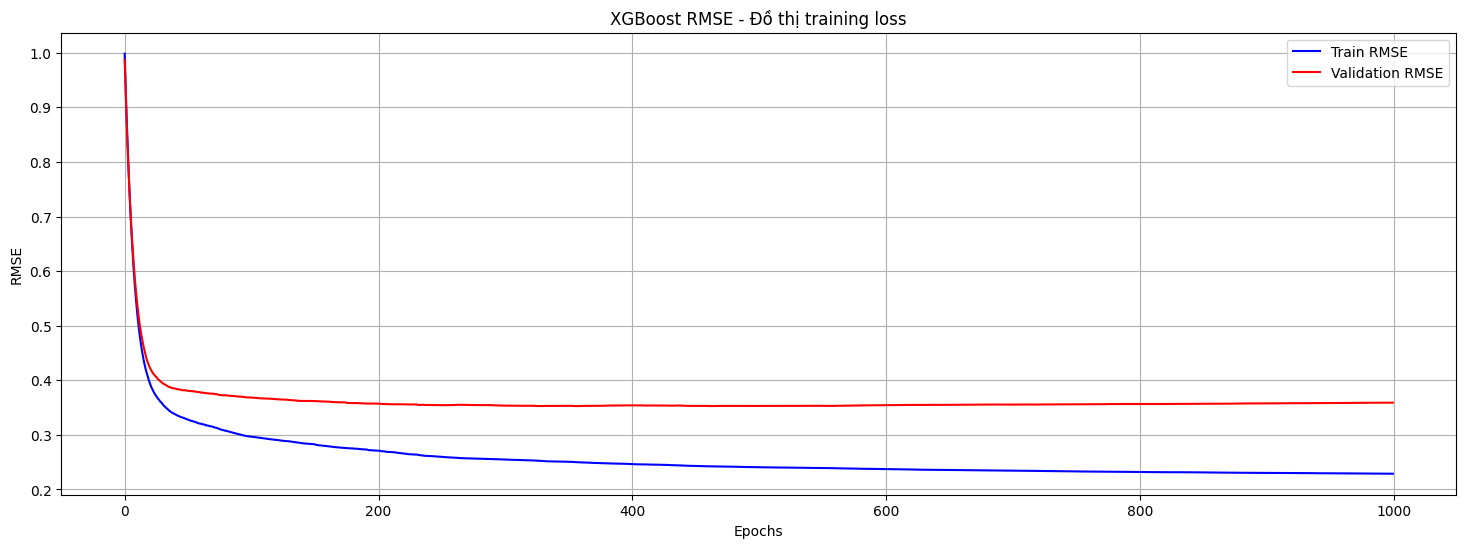

In [20]:
eval_results = model.evals_result()

plt.figure(figsize=(18, 6))
epochs = len(eval_results['validation_1']['rmse'])
x_axis = range(0, epochs)

plt.plot(x_axis, eval_results['validation_0']['rmse'], 'b-', label='Train RMSE')
plt.plot(x_axis, eval_results['validation_1']['rmse'], 'r-', label='Validation RMSE')

plt.title('XGBoost RMSE - Đồ thị training loss')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

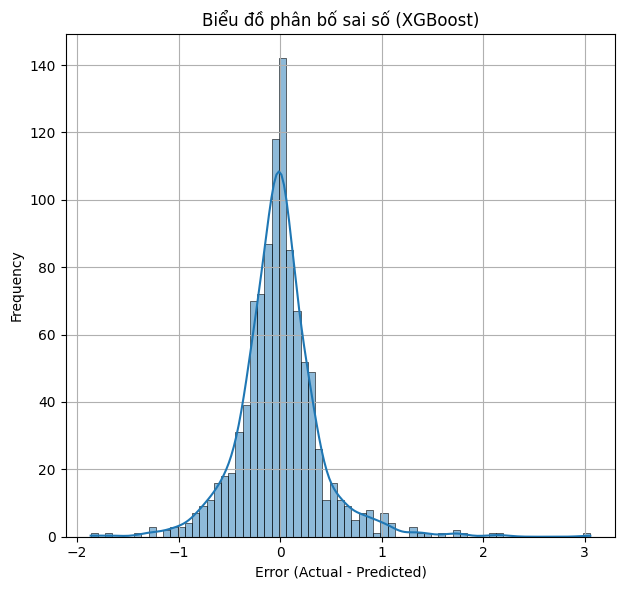

In [21]:
y_test_pred = model.predict(X_test_enc)
errors = y_test - y_test_pred

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(errors, kde=True)
plt.title('Biểu đồ phân bố sai số (XGBoost)')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

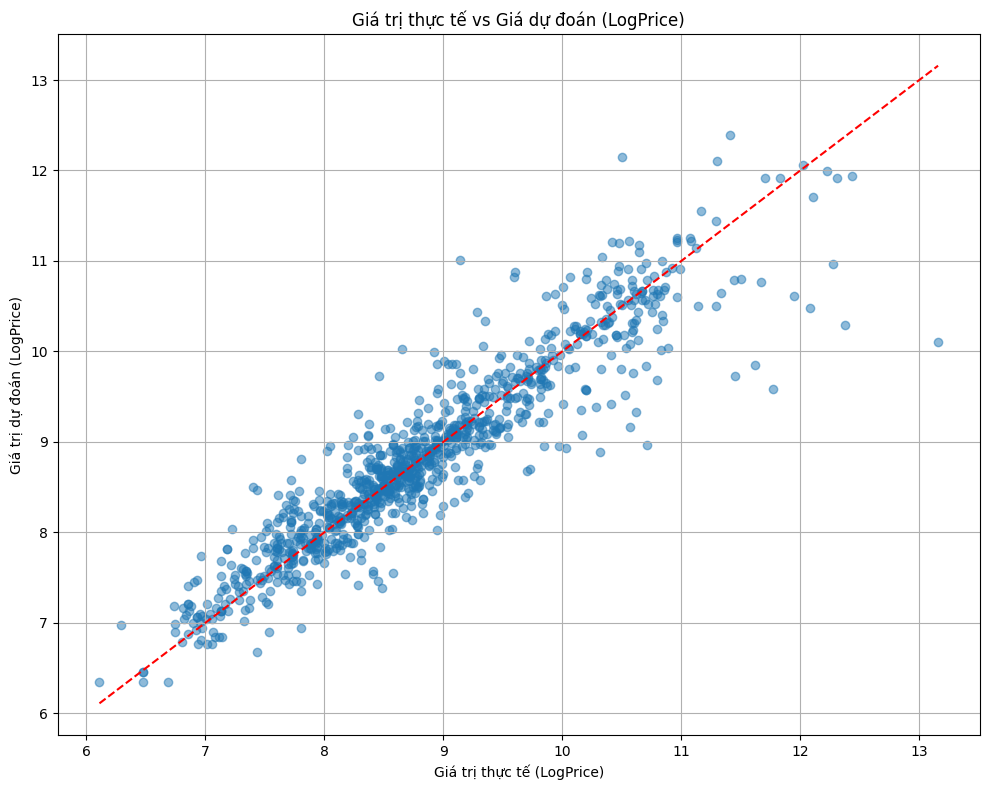

In [22]:
plt.figure(figsize=(10, 8))

plt.scatter(y_test, y_test_pred, alpha=0.5)

max_val = max(max(y_test), max(y_test_pred))
min_val = min(min(y_test), min(y_test_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.title('Giá trị thực tế vs Giá dự đoán (LogPrice)')
plt.xlabel('Giá trị thực tế (LogPrice)')
plt.ylabel('Giá trị dự đoán (LogPrice)')
plt.grid(True)
plt.tight_layout()
plt.show()

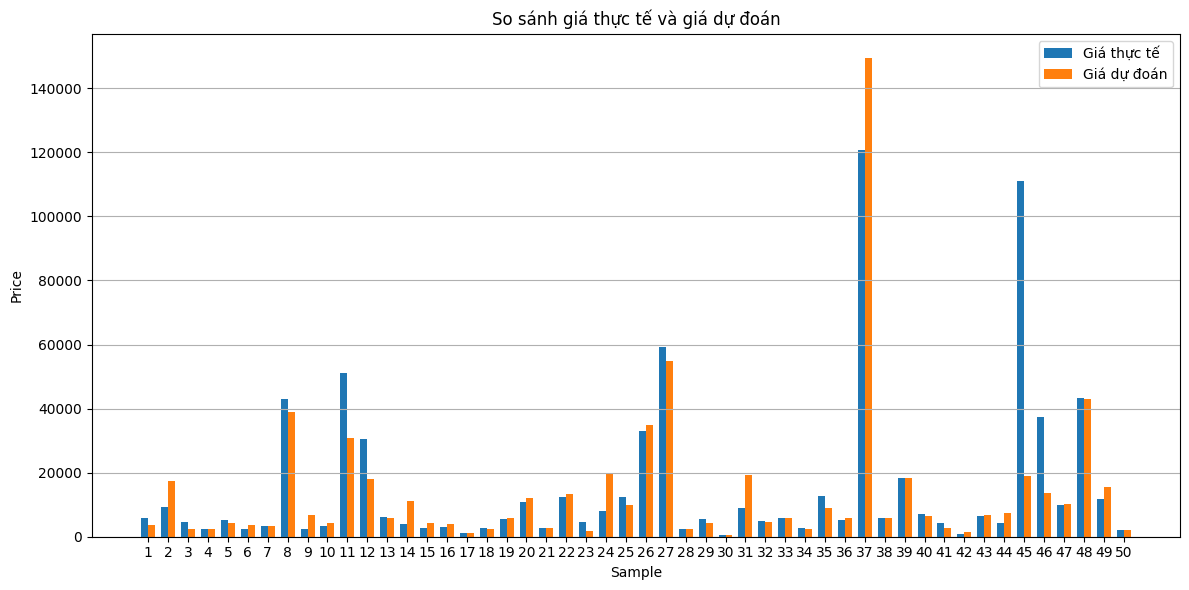

In [23]:
sample_indices = np.random.choice(range(len(y_test)), size=50, replace=False)

actual_prices = np.exp(y_test.iloc[sample_indices])
predicted_prices = np.exp(y_test_pred[sample_indices])

results_df = pd.DataFrame({
    'Sample': range(1, 51),
    'Actual Price': actual_prices.values,
    'Predicted Price': predicted_prices
})

plt.figure(figsize=(12, 6))

x = np.arange(len(sample_indices))  
width = 0.35  

plt.bar(x - width/2, results_df['Actual Price'], width, label='Giá thực tế')
plt.bar(x + width/2, results_df['Predicted Price'], width, label='Giá dự đoán')

plt.xlabel('Sample')
plt.ylabel('Price')
plt.title('So sánh giá thực tế và giá dự đoán')
plt.xticks(x, results_df['Sample'])
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()